In [1]:
!git clone https://github.com/mansourhas/AIMS-KTT-day-2

Cloning into 'AIMS-KTT-day-2'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 14 (delta 4), reused 12 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 68.31 KiB | 2.07 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [2]:
%cd AIMS-KTT-day-2

/content/AIMS-KTT-day-2


In [4]:
!git pull

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 8 (delta 1), reused 8 (delta 1), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 180.99 KiB | 2.29 MiB/s, done.
From https://github.com/mansourhas/AIMS-KTT-day-2
   ccff134..1460092  main       -> origin/main
Updating ccff134..1460092
Fast-forward
 dataset/appliances.json    |   72 +
 dataset/businesses.json    |   32 +
 dataset/grid_history.csv   | 4321 ++++++++++++++++++++++++++++++++++++++++++++
 scripts/data_generation.py |  166 ++
 4 files changed, 4591 insertions(+)
 create mode 100644 dataset/appliances.json
 create mode 100644 dataset/businesses.json
 create mode 100644 dataset/grid_history.csv
 create mode 100644 scripts/data_generation.py


In [18]:
import pandas as pd
import numpy as np
import time
import warnings
from sklearn.metrics import brier_score_loss, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
import xgboost as xgb
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

def load_and_engineer_features(csv_path="dataset/grid_history.csv"):
    """
    Loads grid history and engineers strictly lagging/historical features
    to prevent temporal data leakage.
    """
    df = pd.read_csv(csv_path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)

    # 1. Cyclical Time Features (Hour of day, Day of week)
    # This helps tree models understand weekly seasonality and daily peaks natively
    df['hour'] = df['timestamp'].dt.hour
    df['dayofweek'] = df['timestamp'].dt.dayofweek
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)
    df['day_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7.0)
    df['day_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7.0)

    # 2. Lagged Features (The 'load_lag1' constraint)
    # We shift by 1 hour to ensure predicting hour T only uses data up to T-1
    df['load_lag1'] = df['load_mw'].shift(1)
    df['rain_lag1'] = df['rain_mm'].shift(1)
    df['temp_lag1'] = df['temp_c'].shift(1)

    # 3. Rolling Window Features (Capture the build-up to an outage)
    df['load_rolling_3h'] = df['load_mw'].shift(1).rolling(window=3).mean()
    df['rain_rolling_6h'] = df['rain_mm'].shift(1).rolling(window=6).sum()

    df['load_lag24'] = df['load_mw'].shift(24)
    df['load_volatility_3h'] = df['load_mw'].shift(1).rolling(window=3).std()
    df['rain_load_interaction'] = df['rain_lag1'] * df['load_lag1']

    # Drop NaNs created by lagging/rolling
    df = df.dropna().reset_index(drop=True)

    return df

# Execute
df = load_and_engineer_features('dataset/grid_history.csv')
print(f"Dataset ready. Shape: {df.shape}")

Dataset ready. Shape: (4296, 22)


In [11]:
from sklearn.model_selection import ParameterGrid

def generate_grid_configs():
    """
    Dynamically generates a massive dictionary of model configurations
    to brute-force the best possible hyperparameter combination.
    """
    configs = {}

    # --- LightGBM Grid ---
    lgb_param_grid = {
        'n_estimators': [500, 1000, 2000],
        'learning_rate': [0.01, 0.05],
        'max_depth': [5, 7, 9],
        'num_leaves': [31, 64, 128],
        'colsample_bytree': [0.8, 1.0] # Feature subsampling to fight overfitting
    }

    for i, params in enumerate(ParameterGrid(lgb_param_grid)):
        name = f"LGB_n{params['n_estimators']}_lr{params['learning_rate']}_d{params['max_depth']}_l{params['num_leaves']}_c{params['colsample_bytree']}"
        configs[name] = {
            'clf': lgb.LGBMClassifier(**params, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1),
            'reg': lgb.LGBMRegressor(**params, objective='mae', random_state=42, n_jobs=-1, verbose=-1)
        }

    # --- XGBoost Grid ---
    xgb_param_grid = {
        'n_estimators': [500, 1000],
        'learning_rate': [0.01, 0.05],
        'max_depth': [4, 6, 8],
        'subsample': [0.8, 1.0] # Row subsampling
    }

    for i, params in enumerate(ParameterGrid(xgb_param_grid)):
        name = f"XGB_n{params['n_estimators']}_lr{params['learning_rate']}_d{params['max_depth']}_s{params['subsample']}"
        configs[name] = {
            'clf': xgb.XGBClassifier(**params, scale_pos_weight=24, eval_metric='logloss', random_state=42, n_jobs=-1),
            'reg': xgb.XGBRegressor(**params, objective='reg:absoluteerror', random_state=42, n_jobs=-1)
        }

    return configs

# Generate the massive grid (100+ models)
# configs = generate_grid_configs()
print(f"Total configurations to test: {len(configs)}")
print("Beginning exhaustive grid search. This will take a while...")

# The rest of Cell 2 remains the same:
# results_df = evaluate_models(df, features, target_prob, target_dur)
# ...

Total configurations to test: 132
Beginning exhaustive grid search. This will take a while...


In [19]:
# Define features and targets
features = [
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'load_lag1', 'rain_lag1', 'temp_lag1', 'load_rolling_3h', 'rain_rolling_6h'
]
target_prob = 'outage'
target_dur = 'duration_min'

# TimeSeriesSplit prevents data leakage by always training on the past to predict the future
tscv = TimeSeriesSplit(n_splits=3)

# Model Configurations to test
# Note: scale_pos_weight is CRITICAL for the 4% base rate class imbalance
# Note: objective='mae' prevents the LogNormal duration tail from skewing predictions

# configs = {
#     'LightGBM_Base': {
#         'clf': lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, class_weight='balanced', random_state=42),
#         'reg': lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, objective='mae', random_state=42)
#     },
#     'LightGBM_Heavy': {
#         'clf': lgb.LGBMClassifier(n_estimators=500, max_depth=7, num_leaves=64, learning_rate=0.01, class_weight='balanced', random_state=42),
#         'reg': lgb.LGBMRegressor(n_estimators=500, max_depth=7, num_leaves=64, learning_rate=0.01, objective='mae', random_state=42)
#     },
#     'XGBoost_Base': {
#         'clf': xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, scale_pos_weight=24, eval_metric='logloss', random_state=42),
#         'reg': xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, objective='reg:absoluteerror', random_state=42)
#     },
#     'XGBoost_Heavy': {
#         'clf': xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.01, scale_pos_weight=24, eval_metric='logloss', random_state=42),
#         'reg': xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.01, objective='reg:absoluteerror', random_state=42)
#     }
# }

configs = generate_grid_configs()

results = []

for model_name, models in configs.items():
    print(f"--- Evaluating {model_name} ---")
    clf = models['clf']
    reg = models['reg']

    brier_scores = []
    mae_scores = []
    inference_times = []

    for train_idx, test_idx in tscv.split(df):
        train_data, test_data = df.iloc[train_idx], df.iloc[test_idx]

        X_train, y_train_prob = train_data[features], train_data[target_prob]
        X_test, y_test_prob = test_data[features], test_data[target_prob]

        # 1. Train Classifier (Probabilistic)
        clf.fit(X_train, y_train_prob)

        # 2. Train Regressor (ONLY on rows where an actual outage occurred)
        train_outages = train_data[train_data[target_prob] == 1]
        X_train_reg = train_outages[features]
        y_train_dur = train_outages[target_dur]
        reg.fit(X_train_reg, y_train_dur)

        # --- Inference & Metrics ---

        # Measure Latency (Simulating a 24-hour ahead API call)
        # We take a sample of 24 rows to mimic a standard daily API payload
        sample_24h = X_test.head(24)
        start_time = time.perf_counter()
        _ = clf.predict_proba(sample_24h)[:, 1]
        _ = reg.predict(sample_24h)
        end_time = time.perf_counter()

        latency_ms = (end_time - start_time) * 1000
        inference_times.append(latency_ms)

        # Predict Probabilities
        preds_prob = clf.predict_proba(X_test)[:, 1]
        brier = brier_score_loss(y_test_prob, preds_prob)
        brier_scores.append(brier)

        # Predict Duration (Evaluate MAE ONLY where true outages happened)
        test_outages = test_data[test_data[target_prob] == 1]
        if len(test_outages) > 0:
            X_test_reg = test_outages[features]
            y_test_dur = test_outages[target_dur]
            preds_dur = reg.predict(X_test_reg)
            mae = mean_absolute_error(y_test_dur, preds_dur)
            mae_scores.append(mae)

    # Aggregate results
    results.append({
        'Model': model_name,
        'Avg_Brier_Score': np.mean(brier_scores),
        'Avg_MAE_Duration': np.mean(mae_scores),
        'Latency_24h_ms': np.mean(inference_times)
    })




# Execute Evaluation
results_df = pd.DataFrame(results)
display(results_df)

--- Evaluating LGB_n500_lr0.01_d5_l31_c0.8 ---
--- Evaluating LGB_n500_lr0.01_d5_l64_c0.8 ---
--- Evaluating LGB_n500_lr0.01_d5_l128_c0.8 ---
--- Evaluating LGB_n1000_lr0.01_d5_l31_c0.8 ---
--- Evaluating LGB_n1000_lr0.01_d5_l64_c0.8 ---
--- Evaluating LGB_n1000_lr0.01_d5_l128_c0.8 ---
--- Evaluating LGB_n2000_lr0.01_d5_l31_c0.8 ---
--- Evaluating LGB_n2000_lr0.01_d5_l64_c0.8 ---
--- Evaluating LGB_n2000_lr0.01_d5_l128_c0.8 ---
--- Evaluating LGB_n500_lr0.01_d7_l31_c0.8 ---
--- Evaluating LGB_n500_lr0.01_d7_l64_c0.8 ---
--- Evaluating LGB_n500_lr0.01_d7_l128_c0.8 ---
--- Evaluating LGB_n1000_lr0.01_d7_l31_c0.8 ---
--- Evaluating LGB_n1000_lr0.01_d7_l64_c0.8 ---
--- Evaluating LGB_n1000_lr0.01_d7_l128_c0.8 ---
--- Evaluating LGB_n2000_lr0.01_d7_l31_c0.8 ---
--- Evaluating LGB_n2000_lr0.01_d7_l64_c0.8 ---
--- Evaluating LGB_n2000_lr0.01_d7_l128_c0.8 ---
--- Evaluating LGB_n500_lr0.01_d9_l31_c0.8 ---
--- Evaluating LGB_n500_lr0.01_d9_l64_c0.8 ---
--- Evaluating LGB_n500_lr0.01_d9_l128_c0.

,Model,Avg_Brier_Score,Avg_MAE_Duration,Latency_24h_ms
0,LGB_n500_lr0.01_d5_l31_c0.8,0.094800,42.214970,5.169080
1,LGB_n500_lr0.01_d5_l64_c0.8,0.094800,42.214970,9.741178
2,LGB_n500_lr0.01_d5_l128_c0.8,0.094800,42.214970,7.032183
3,LGB_n1000_lr0.01_d5_l31_c0.8,0.061620,42.017131,5.487279
4,LGB_n1000_lr0.01_d5_l64_c0.8,0.061620,42.017131,4.969502
...,...,...,...,...
127,XGB_n1000_lr0.05_d6_s1.0,0.030977,47.040062,16.636340
128,XGB_n500_lr0.05_d8_s0.8,0.028835,45.884219,7.149921
129,XGB_n500_lr0.05_d8_s1.0,0.029862,45.627562,6.999592
130,XGB_n1000_lr0.05_d8_s0.8,0.028644,45.886056,8.555742


In [ ]:
import plotly.express as px

def plot_model_tradeoffs_interactive(results_df):
    # Create a new column to distinguish the algorithm family for color coding
    results_df['Algorithm'] = results_df['Model'].apply(lambda x: 'LightGBM' if 'LGB' in x else 'XGBoost')

    fig = px.scatter(
        results_df,
        x='Avg_Brier_Score',
        y='Latency_24h_ms',
        color='Algorithm',
        hover_name='Model',           # Shows the exact grid params on hover
        hover_data=['Avg_MAE_Duration'], # Adds MAE to the tooltip
        title='Grid Search Results: Brier Score vs. Latency (Hover for details)',
        labels={
            'Avg_Brier_Score': 'Brier Score (Lower is Better)',
            'Latency_24h_ms': 'Inference Latency (ms)'
        }
    )

    # Add the 300ms constraint line
    fig.add_hline(y=300, line_dash="dash", line_color="red", annotation_text="Max API Latency (300ms)")

    # Dynamically zoom the Y-axis so we aren't squashed by the 300ms line
    max_latency = results_df['Latency_24h_ms'].max()
    fig.update_yaxes(range=[0, max_latency * 1.5])

    fig.show()

# Execute interactive plot
plot_model_tradeoffs_interactive(results_df)

![newplot (1).png](<attachment:newplot (1).png>)

In [17]:
# Show the absolute best model by lowest Brier Score
display(results_df.sort_values('Avg_Brier_Score').head(5))

,Model,Avg_Brier_Score,Avg_MAE_Duration,Latency_24h_ms,Algorithm
103,LGB_n1000_lr0.05_d9_l64_c1.0,0.027745,41.671300,8.163047,LightGBM
102,LGB_n1000_lr0.05_d9_l31_c1.0,0.027845,41.671300,10.006126,LightGBM
106,LGB_n2000_lr0.05_d9_l64_c1.0,0.027883,41.654612,11.908785,LightGBM
41,LGB_n1000_lr0.05_d7_l128_c0.8,0.027931,41.970272,5.676667,LightGBM
40,LGB_n1000_lr0.05_d7_l64_c0.8,0.027940,41.970272,8.049271,LightGBM


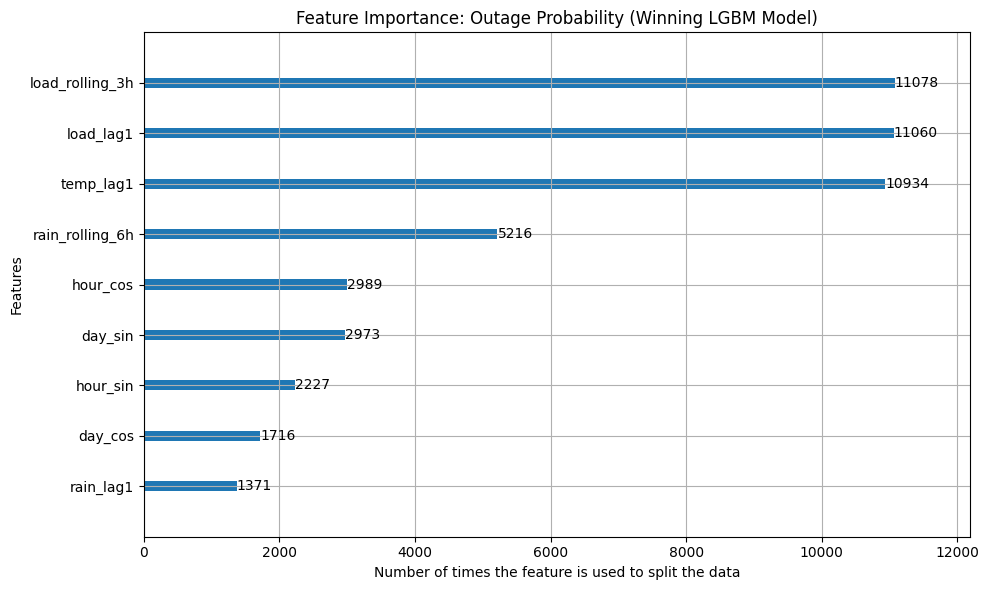

In [23]:
import matplotlib.pyplot as plt

# 1. Initialize the absolute best model from your grid search
winning_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=9,
    num_leaves=64,
    colsample_bytree=1.0,
    class_weight='balanced',
    random_state=42
)

# 2. Fit the model on your features and target
# (Make sure df, features, and target_prob are still defined from Cell 1/2)
winning_model.fit(df[features], df[target_prob])

# 3. Plot the Feature Importance
# We adjust the figsize to make it look clean for your presentation screenshots
plt.rcParams["figure.figsize"] = (10, 6)

# importance_type='split' shows how many times a feature is used to split the data across all 1000 trees.
# You can also use importance_type='gain' to see which features provide the most accuracy improvement.
lgb.plot_importance(
    winning_model,
    max_num_features=10,
    importance_type='split',
    title="Feature Importance: Outage Probability (Winning LGBM Model)",
    xlabel="Number of times the feature is used to split the data",
    ylabel="Features",
    grid=True
)

plt.tight_layout()
plt.show()

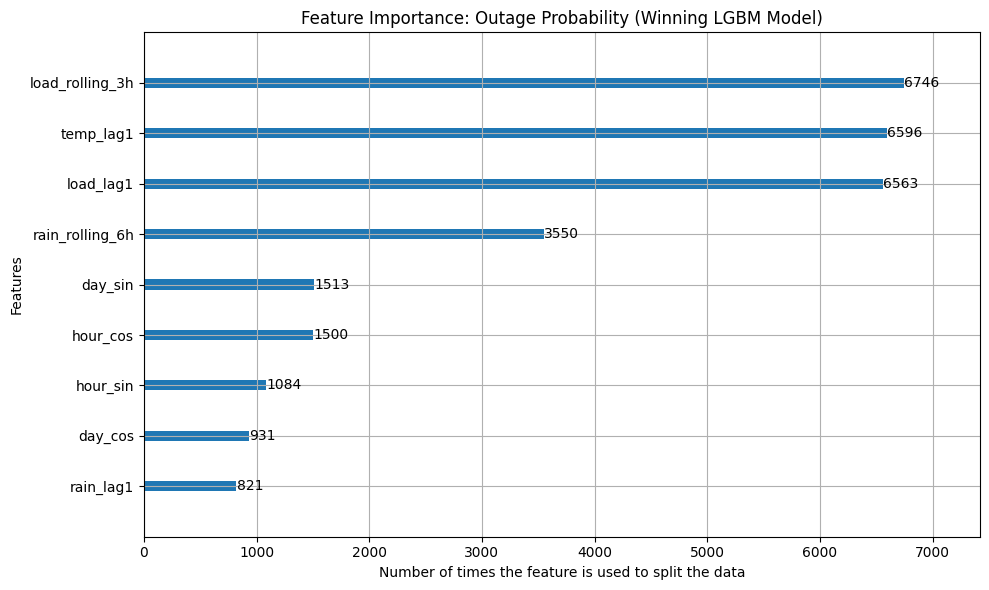

In [24]:
import matplotlib.pyplot as plt

# 1. Initialize the absolute best model from your grid search
winning_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=9,
    num_leaves=64,
    colsample_bytree=1.0,
    class_weight='balanced',
    min_child_samples=50,
    random_state=42
)

# 2. Fit the model on your features and target
# (Make sure df, features, and target_prob are still defined from Cell 1/2)
winning_model.fit(df[features], df[target_prob])

# 3. Plot the Feature Importance
# We adjust the figsize to make it look clean for your presentation screenshots
plt.rcParams["figure.figsize"] = (10, 6)

# importance_type='split' shows how many times a feature is used to split the data across all 1000 trees.
# You can also use importance_type='gain' to see which features provide the most accuracy improvement.
lgb.plot_importance(
    winning_model,
    max_num_features=10,
    importance_type='split',
    title="Feature Importance: Outage Probability (Winning LGBM Model)",
    xlabel="Number of times the feature is used to split the data",
    ylabel="Features",
    grid=True
)

plt.tight_layout()
plt.show()

In [25]:
import time
import numpy as np
import pandas as pd
from sklearn.metrics import brier_score_loss, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb

# 1. Redefine features to EXCLUDE the noisy 'temp_lag1'
realistic_features = [
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'load_lag1', 'rain_lag1', 'load_rolling_3h', 'rain_rolling_6h'
]

# 2. Define the Realistic Model with the Anti-Overfitting Parameter
# min_child_samples=50 forces the tree to stop splitting if a leaf has fewer than 50 hours of data
realistic_clf = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=9,
    num_leaves=64,
    colsample_bytree=1.0,
    min_child_samples=50,
    class_weight='balanced',
    random_state=42
)

realistic_reg = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=9,
    num_leaves=64,
    colsample_bytree=1.0,
    min_child_samples=50,
    objective='mae',
    random_state=42
)

# 3. Evaluate using the strict TimeSeriesSplit (Rolling Window)
tscv = TimeSeriesSplit(n_splits=3)
brier_scores = []
mae_scores = []
latencies = []

print("Evaluating Realistic LGBM Model (No Temp, Min Child = 50)...")

for train_idx, test_idx in tscv.split(df):
    train_data, test_data = df.iloc[train_idx], df.iloc[test_idx]

    X_train, y_train_prob = train_data[realistic_features], train_data[target_prob]
    X_test, y_test_prob = test_data[realistic_features], test_data[target_prob]

    # Train Classifier
    realistic_clf.fit(X_train, y_train_prob)

    # Train Regressor on Outages Only
    train_outages = train_data[train_data[target_prob] == 1]
    if len(train_outages) > 0:
        realistic_reg.fit(train_outages[realistic_features], train_outages[target_dur])

    # Inference Latency Test (24h batch)
    sample_24h = X_test.head(24)
    start_time = time.perf_counter()
    _ = realistic_clf.predict_proba(sample_24h)[:, 1]
    _ = realistic_reg.predict(sample_24h)
    latencies.append((time.perf_counter() - start_time) * 1000)

    # Metrics Calculation
    preds_prob = realistic_clf.predict_proba(X_test)[:, 1]
    brier_scores.append(brier_score_loss(y_test_prob, preds_prob))

    test_outages = test_data[test_data[target_prob] == 1]
    if len(test_outages) > 0:
        preds_dur = realistic_reg.predict(test_outages[realistic_features])
        mae_scores.append(mean_absolute_error(test_outages[target_dur], preds_dur))

# 4. Output the final realistic metrics
print("-" * 30)
print(f"Realistic Brier Score:  {np.mean(brier_scores):.5f}")
print(f"Realistic MAE Duration: {np.mean(mae_scores):.2f} minutes")
print(f"24h Inference Latency:  {np.mean(latencies):.2f} ms")
print("-" * 30)

Evaluating Realistic LGBM Model (No Temp, Min Child = 50)...
------------------------------
Realistic Brier Score:  0.03275
Realistic MAE Duration: 43.08 minutes
24h Inference Latency:  10.19 ms
------------------------------
